In [41]:

import matplotlib.pyplot as plt
import pandas as pd

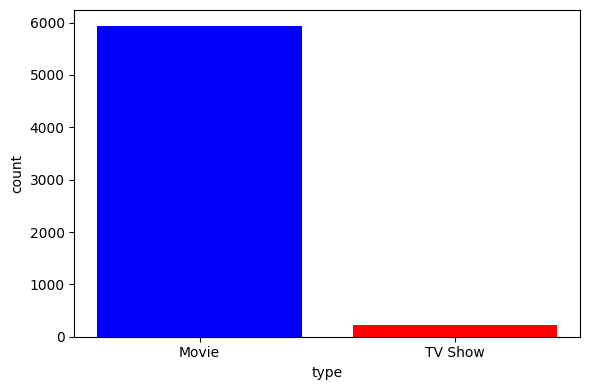

In [42]:
df = pd.read_csv("netflix_titles.csv")
df = df.dropna(subset=['type','title','director'])
typeCounts = df['type'].value_counts()

plt.figure(figsize=(6,4))
plt.bar(typeCounts.index,typeCounts.values,color=['blue','red'])
plt.xlabel("type")
plt.ylabel("count")
plt.tight_layout()  
plt.savefig("netflixShowToMovie.png",dpi =300,bbox_inches='tight')

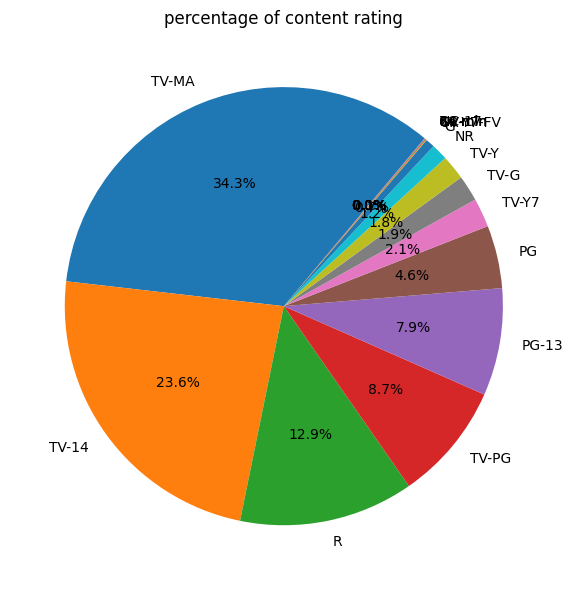

In [43]:
ratingcount = df['rating'].value_counts()
plt.figure(figsize=(8,6))
plt.pie(ratingcount,labels=ratingcount.index,autopct='%1.1f%%',startangle=50)
plt.title("percentage of content rating")
plt.tight_layout()  
plt.savefig("contentRating.png",dpi =300,bbox_inches='tight')

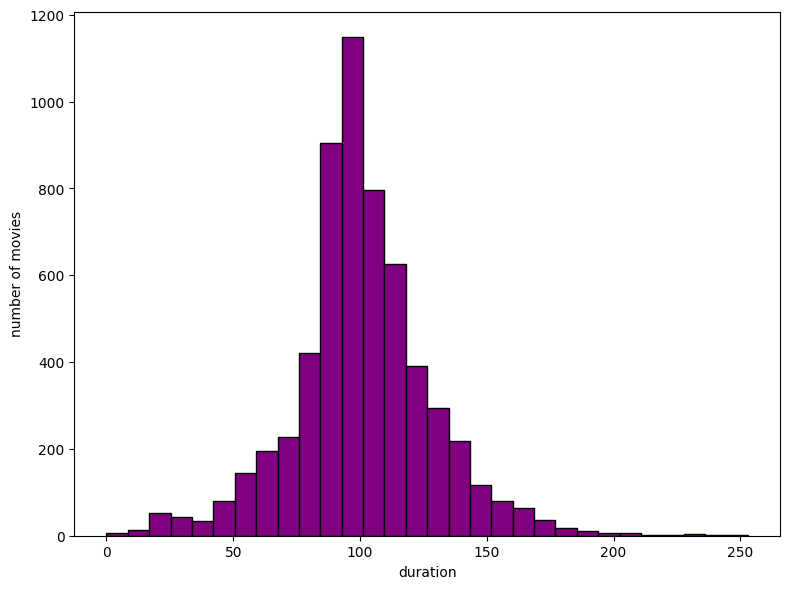

In [44]:
movie_df  = df[df['type']=='Movie'].copy()
movie_df["duration_int"] = movie_df["duration"].str.replace(" min", "").fillna(0).astype(int)

plt.figure(figsize=(8,6))
plt.hist(movie_df['duration_int'],bins=30,color = 'purple',edgecolor='black')
plt.xlabel("duration")
plt.ylabel("number of movies")
plt.tight_layout()  
plt.savefig("histogram.png",dpi =300,bbox_inches='tight')

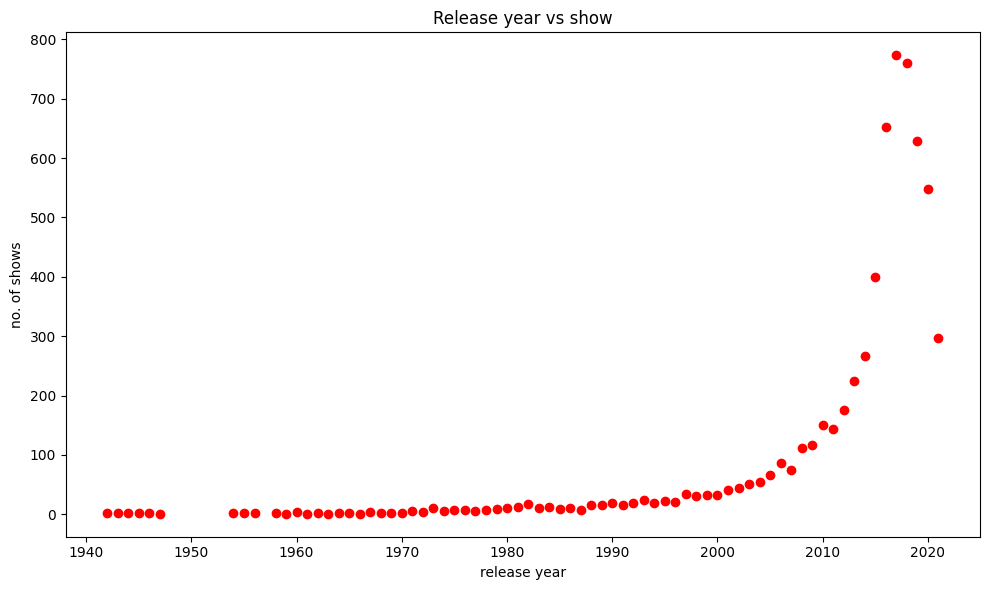

In [45]:
res = df['release_year'].value_counts().sort_index()
plt.figure(figsize=(10,6))
plt.scatter(res.index,res.values,color='red')
plt.title("Release year vs show")
plt.xlabel("release year")
plt.ylabel("no. of shows")
plt.tight_layout()  
plt.savefig("releaseYear.png",dpi =300,bbox_inches='tight')

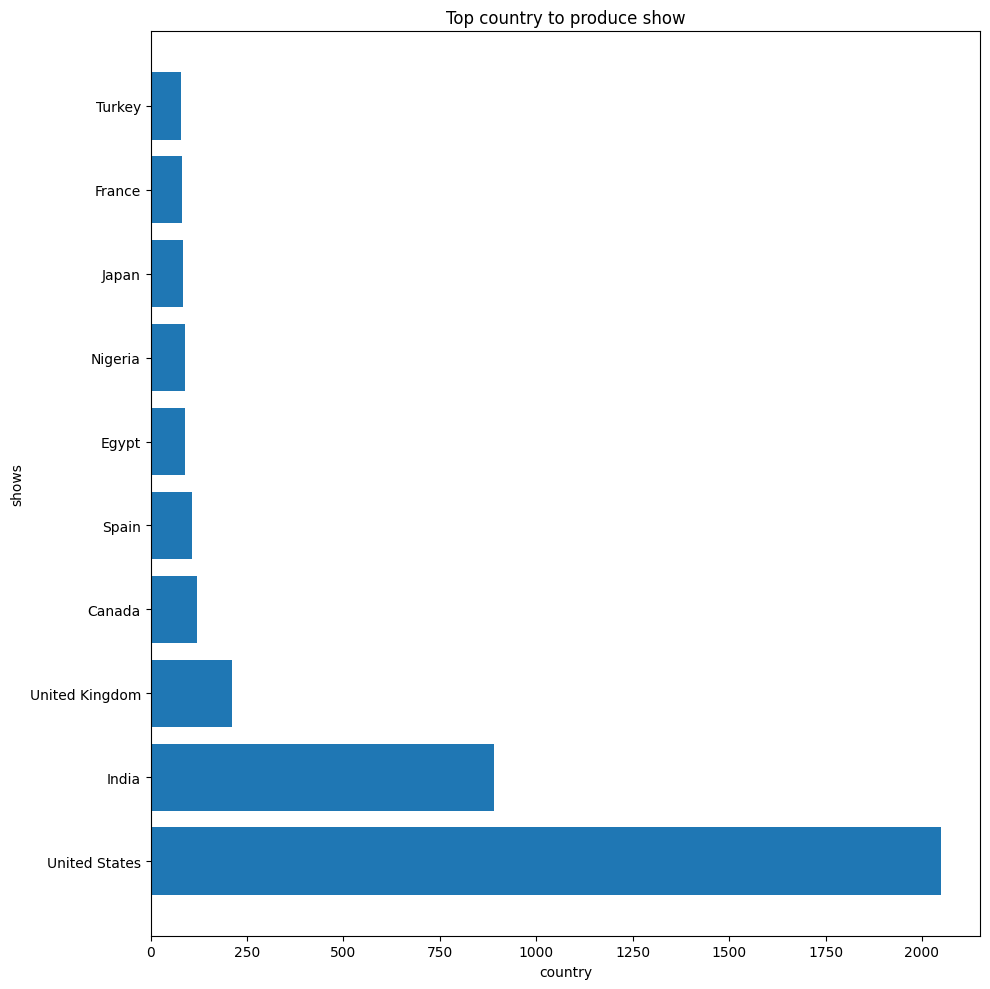

In [46]:
con = df['country'].value_counts().head(10)
plt.figure(figsize=(10,10))
plt.barh(con.index,con.values)
plt.xlabel("country")
plt.ylabel("shows")
plt.title("Top country to produce show")
plt.tight_layout()  
plt.savefig("topcounret.png",dpi =300,bbox_inches='tight')


type          Movie  TV Show
release_year                
1942            2.0      0.0
1943            3.0      0.0
1944            3.0      0.0
1945            3.0      0.0
1946            1.0      1.0
...             ...      ...
2017          748.0     25.0
2018          737.0     23.0
2019          598.0     31.0
2020          495.0     53.0
2021          252.0     45.0

[73 rows x 2 columns]


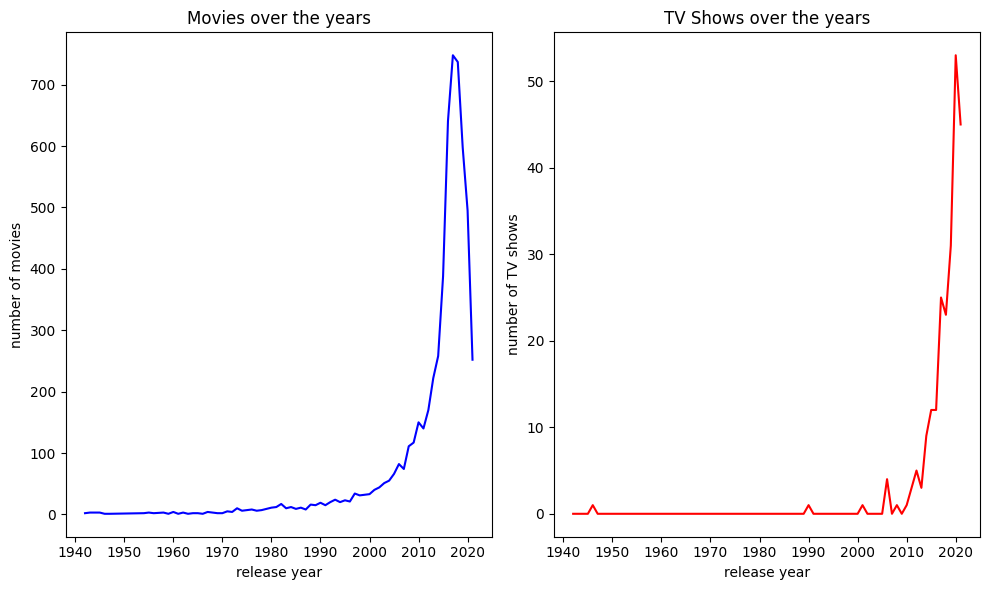

In [47]:
contentyear=df.groupby(['release_year','type']).size().unstack().fillna(0)
print(contentyear)
fig,ax = plt.subplots(1,2,figsize=(10,6))
ax[0].plot(contentyear.index,contentyear['Movie'],color='blue')
ax[0].set_title("Movies over the years")
ax[0].set_xlabel("release year")
ax[0].set_ylabel("number of movies")
ax[1].plot(contentyear.index,contentyear['TV Show'],color='red')
ax[1].set_title("TV Shows over the years")
ax[1].set_xlabel("release year")
ax[1].set_ylabel("number of TV shows")

plt.tight_layout()
plt.savefig("movietvshow.png",dpi =300,bbox_inches='tight')